1. Load dataset

In [ ]:
import pandas as pd

# Load the dataset
# index_col=0 tells pandas to use  first column as index
df = pd.read_csv('food.csv', index_col=0)

# Show the first few rows just to make sure it looks right
print(df.head())

                RedMeat  WhiteMeat  Eggs  Milk  Fish  Cereals  Starch  Nuts  \
Albania            10.1        1.4   0.5   8.9   0.2     42.3     0.6   5.5   
Austria             8.9       14.0   4.3  19.9   2.1     28.0     3.6   1.3   
Belgium            13.5        9.3   4.1  17.5   4.5     26.6     5.7   2.1   
Bulgaria            7.8        6.0   1.6   8.3   1.2     56.7     1.1   3.7   
Czechoslovakia      9.7       11.4   2.8  12.5   2.0     34.3     5.0   1.1   

                Fr.Veg  
Albania            1.7  
Austria            4.3  
Belgium            4.0  
Bulgaria           4.2  
Czechoslovakia     4.0  


2. Analyze dataset

In [4]:
# Check the dimensions (rows, columns)
print("Data Dimensions:")
print(df.shape)

# Count any missing values in the columns
print("\nMissing Values per Feature:")
print(df.isnull().sum())

# Get the statistical summary (mean, std, min, max, etc.)
print("\nFeature Statistics:")
print(df.describe())

Data Dimensions:
(25, 9)

Missing Values per Feature:
RedMeat      0
WhiteMeat    0
Eggs         0
Milk         0
Fish         0
Cereals      0
Starch       0
Nuts         0
Fr.Veg       0
dtype: int64

Feature Statistics:
         RedMeat  WhiteMeat       Eggs       Milk       Fish    Cereals  \
count  25.000000  25.000000  25.000000  25.000000  25.000000  25.000000   
mean    9.828000   7.896000   2.936000  17.112000   4.284000  32.248000   
std     3.347078   3.694081   1.117617   7.105416   3.402533  10.974786   
min     4.400000   1.400000   0.500000   4.900000   0.200000  18.600000   
25%     7.800000   4.900000   2.700000  11.100000   2.100000  24.300000   
50%     9.500000   7.800000   2.900000  17.600000   3.400000  28.000000   
75%    10.600000  10.800000   3.700000  23.300000   5.800000  40.100000   
max    18.000000  14.000000   4.700000  33.700000  14.200000  56.700000   

          Starch       Nuts     Fr.Veg  
count  25.000000  25.000000  25.000000  
mean    4.276000   

3. Preprocess data

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Apply the transformation to our data
# This calculates the mean and standard deviation for each column 
# and then scales the values.
food_scaled = scaler.fit_transform(df)

4. Perform PCA

In [ ]:
from sklearn.decomposition import PCA

# 1. Initialize PCA and set the number of components to 2
pca = PCA(n_components=2)

# 2. Fit and transform the scaled data
pca_data = pca.fit_transform(food_scaled)

# Let's see the shape to confirm it worked (should be 25 rows, 2 columns)
print("PCA results shape:", pca_data.shape)

PCA results shape: (25, 2)


5. Create score plot

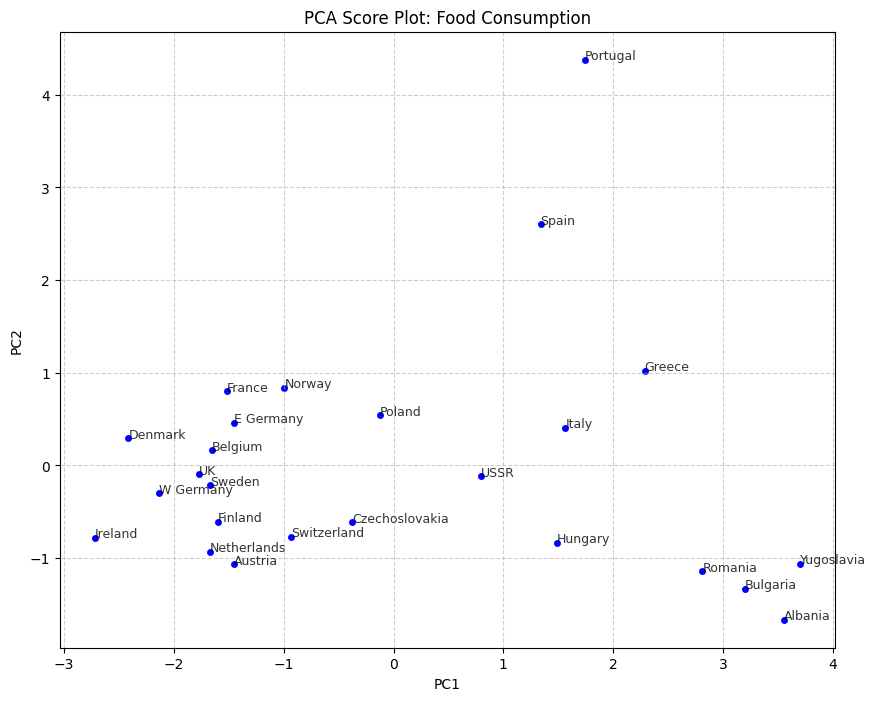

In [ ]:
import matplotlib.pyplot as plt

# 1. Setup the figure size
plt.figure(figsize=(10, 8))

# 2. Create the scatter plot using the two columns from our PCA data
# pca_data[:, 0] is PC1, pca_data[:, 1] is PC2
plt.scatter(pca_data[:, 0], pca_data[:, 1], c='blue', edgecolors='white')

# 3. Label the axes (as requested in the task)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Score Plot: Food Consumption')

# 4. Add the country names so we know which dot is which
for i, country in enumerate(df.index):
    plt.annotate(country, (pca_data[i, 0], pca_data[i, 1]), fontsize=9, alpha=0.8)

# 5. Add a grid to make it look cleaner
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()